<a href="https://colab.research.google.com/github/bobroberts2639/Pangolin-Security-Consulting-Services-tutte-institute-acme3/blob/main/acme3_mapping__2_command_lines_wasserstein_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 of 6 of TutteInstitute/acm3-mapping

<div>
<img src="https://connoiter.com/images/tutte/king_tutte_on_colab.transparent_bg.png" align="left" width="200px"/>

Note: this is the third of the six notebooks in TutteInstitute/acm3-mapping. The first one is numbered 0.

This notebook, [acme3-mapping__2_command_lines_wasserstein_embedding.ipynb](https://github.com/Connoiter/king_tutte_datamap_codex/tree/main/by_repo/acme3-mapping/acme-mapping__0_Gather_and_engineer_dataset.ipynb), is part of [the King Tutte Datamap Codex repo](https://github.com/Connoiter/king_tutte_datamap_codex), which contains a [Jupyter Book](https://jupyterbook.org/). The Jupyter notebooks in the King Tutte Codex run on Colab, and that fact is essentially the only value of this Codex work: curate and package pre-existing datamap example code and minimally modify the code to run out-of-the-box on Colab. As such, the King Tutte Datamap Codex Jupyter Book consists of King Tutte datamap pipelines that run on Google's Colab.
</div>
<br/>

## Pedigree

This notebook is simply a Colab-ified variant of [2 Command lines - Wasserstein embedding.ipynb](https://github.com/TutteInstitute/acme3-mapping/blob/main/2%20Command%20lines%20-%20Wasserstein%20embedding.ipynb), which is part of the Tutte Institute's repo, [acme3-mapping](https://github.com/TutteInstitute/acme3-mapping).

## What this notebook does

<img src="https://user-images.githubusercontent.com/50601643/218871643-2d3af433-0923-4786-b5e5-24c6a72e803e.png" align="right" height="100px"/>

Lawrence Livermore National Laboratory (LLNL) has produced a tool, [Wintap](https://github.com/LLNL/Wintap), which is [MIT licensed](https://github.com/llnl/Wintap/blob/main/LICENSE). As part of that project, they currated some test data, as explained on [a LLNL website](https://gdo168.llnl.gov/). One of those datasets is known as [ACME 3](https://gdo168.llnl.gov/data/ACME3/).

In Notebook #0, the recorded commandlines of ACME 3 were tokenized. In Notebook #1 they were naively datamapped. This notebook refines the process by using a stop word deemphasizer (the information weight transforms, which can be thought of as a theoretically well-founded replacement for classical TF-IDF) because bag of words techniques are sensitive to stop words. Then Wasserstein embedding are produced and UMAPped.

For the fullest explanation of these six notebooks, watch the 34 minute recording of a SciPy 2024 talk by [one of the authors of the original six notebooks](https://github.com/TutteInstitute/acme3-mapping/graphs/contributors), Benoit Hamelin of the Tutte Institute:

[![Vector space embeddings and data maps for cyber defense](https://img.youtube.com/vi/j1w4WHgtfDg/maxresdefault.jpg)](https://www.youtube.com/watch?v=j1w4WHgtfDg)

For more info, see [the King Tutte repo's acme3-mapping readme](https://github.com/Connoiter/king_tutte_datamap_codex/tree/main/by_repo/acme3-mapping).


For more info (including a long video explanation), see [the repo's acme3-mapping readme](https://github.com/Connoiter/king_tutte_datamap_codex/tree/main/by_repo/acme3-mapping).


In [ ]:
# TODO: explain this
# Set this "CONSTANT" to wherever on Hugging Face the output of Notebook #0 is:
REPO_ID_OF_DATA_ON_HUGGING_FACE = "connoiter/acme3-mapping-TEMP"

## Embedding command lines as distributions on point clouds of token vectors

The data map produced in [notebook 1](Command%20lines%20-%20Bags%20of%20words.ipynb) is nice, but flawed.
Bags of words tend to yield _fragmented_ vector sets,
where similar objects spread across a lot of space, over a large number of vectors.
This makes their joint analysis trickier than it should be.
It also assumes that tokens are independant and order-free, two properties that command line tokens definitely don't satisfy.
Finally, it doesn't learn any of the latent _synonomity semantics_ of the data.
For instance, when using them to embed text, bags of words see words such as _red_, _carmine_ and _scarlet_ as strictly distinct, and inducing dissimilarity between the correpsonding sentences.

We can analyze the token vocabulary by considering how they co-occur with other tokens,
and where.
Co-occurrence helps with finding synonymous tokens,
and bridging similarity gaps that fragment vectors with bags of words.
Let's apply this insight to the analysis of command lines.

---

**Goals of this notebook**:

1. Crunch a vector representation of tokens that takes into account their cooccurrences as a similarity notion.
2. Use these vectors as a _point cloud_ geometric vocabulary on which to express command lines, and derive a vector space embedding of command lines from that -- a technique named **Wasserstein embedding**.
3. Appraise the visible differences between a bag-of-words data map and a Wasserstein data map.

---

## Install packages

One of the hassles encountered while working out how to get this notebook to work on Colab was that vectorizers and Nubmy were clashing. The code:
```python
%%time
vz_cooc = vz.TokenCooccurrenceVectorizer(n_threads=os.cpu_count(), n_iter=3)\
    .fit(cmdlines_tokenized.tolist())
cooc_vec = vz_cooc.reduce_dimension(512)
```
Raised an error:
```
AssertionError: Unreachable condition reached (op code RERAISE executed)
-------------------------------------------------------------------------------
This should not have happened, a problem has occurred in Numba's internals.
You are currently using Numba version 0.60.0.
```

To resolve the error specific version had to be called for durin `pip install`.

[Numba version](https://github.com/numba/numba/releases) experiments:
- 0.63.1 AssertionError (CPU and T4)
- 0.60.0 AssertionError
- 0.59.1 AssertionError
- 0.58.1 python setup.py egg_info did not run successfully.
- 0.57.0 python setup.py egg_info did not run successfully.

In [ ]:
#!pip uninstall -y numba
#!pip install numba==0.63.1
import numba
print(f"Numba version: {numba.__version__}")

Numba version: 0.60.0


In [ ]:
import os
os.cpu_count()

2

## NumPy experiments

Stock is seemingly 2.0.2

- !pip install numpy==1.23.5: failed to install
- !pip install "numpy<2.0.0" (1.26.4)

In [ ]:
!git clone --depth 1 --branch colab-ify https://github.com/JohnTigue/vectorizers.git

fatal: destination path 'vectorizers' already exists and is not an empty directory.


In [ ]:
#!pip uninstall numpy -y
#!pip install "numpy<2.0.0"

In [ ]:
import numpy as np
print(np.__version__)

2.0.2


In [ ]:
import  os
# disabling JIT breaks fast_hdbscan
# os.environ['NUMBA_DISABLE_JIT'] = '1'

In [ ]:
!pip install umap-learn
!pip install datamapplot
!pip install fast_hdbscan
#!pip install vectorizers==0.2.2

TODO: update URL to point to Codex's version

**Attention**: you must first run [notebook 1](Command%20lines%20-%20Bags%20of%20words.ipynb) to get ready to run this one in turn.

In [ ]:
import sys
from pathlib import Path

vectorizers_repo = Path("vectorizers").resolve()
if vectorizers_repo.exists() and str(vectorizers_repo) not in sys.path:
    sys.path.insert(0, str(vectorizers_repo))
for module_name in list(sys.modules):
    if module_name == "vectorizers" or module_name.startswith("vectorizers."):
        del sys.modules[module_name]
print("vectorizers path:", vectorizers_repo)

import datamapplot as dmp
from fast_hdbscan import HDBSCAN
import json
import numpy as np
import os
import pandas as pd
from pathlib import Path
import re
import scipy.sparse
from tqdm.auto import trange
import umap
import vectorizers as vz

vectorizers path: /content/vectorizers


## Gather our tokenized command lines.

The original Tutte Institute notebook assumes that files generated by earlier notebooks (#0 and #1) are sitting in the localhost file system. That is not the case on Colab, so Connoiter has been saving files off to Hugging Face. Now we need to download those Parquet files to make the rest of Tutte's code run as-was.


In [ ]:
from huggingface_hub import hf_hub_download

def download_from_huggingface(repo_id, filename):
    hf_hub_download(
        repo_id=repo_id,
        local_dir=".",
        filename=filename
    )

download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_iwt.npz")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_bagofwords.npz")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_labels_hovertext.parquet")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "color_map.json")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "process_filtered.parquet")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_tokenized.parquet")

In [ ]:
cmdlines_tokenized = pd.read_parquet("cmdlines_tokenized.parquet")["cmdline"]
# MORON: cmdlines_tokenized = pd.read_parquet("process_filtered.parquet")["cmdline"]
cmdlines_tokenized

,cmdline
pid_hash,
45EBAFA4120EBD83795F91B021C2C987,"[""%systemroot%\system32\csrss.exe""]"
C9680E6A5A7B1A976F538CC5A417E0C5,"[""%systemroot%\system32\csrss.exe"", objectdire..."
71A014969332AF0C1E0FBFC883BEB8FF,"[""%systemroot%\system32\musnotificationux.exe""..."
83FB4E68D3AC8DA9B36A19FF158F9410,"[""%systemroot%\system32\musnotificationux.exe""..."
A5F0F3DB7F64C157C48A7CCBFDCCB9DD,"[""%systemroot%\system32\musnotificationux.exe""..."
...,...
2B69DF1A23610FC8D0E5F50A03883E05,"[""usr\bin\bash.exe"", --norc, -c, ""export path=..."
E8574562C96D3A223B0A52389B4EFD3F,"[""usr\bin\mintty.exe"", --nodaemon, -o, appid=g..."
4925BFC824A2B984C2AF2C4EBB7F705F,"[""vboxheadless.exe""]"


Deriving a vector representation of each token based on their cooccurrence in command lines can be done by embedding them using `vectorizers.TokenCooccurrenceVectorizer`.
This takes minutes on a two-year-old MacBook.
It's a good moment to check your e-mail.

Original code:
```python
%%time
vz_cooc = vz.TokenCooccurrenceVectorizer(n_threads=os.cpu_count(), n_iter=3)\
    .fit(cmdlines_tokenized.tolist())
cooc_vec = vz_cooc.reduce_dimension(512)
cooc_vec.shape
```

Hacked while debugging:
```
%%time
# Colab-safe checked cooccurrence build.
# The full corpus fit can run for a very long time on Colab, so use a
# deterministic sample by default. Increase this if the runtime can handle it.
COMMAND_LINE_SAMPLE_SIZE = 5000

sample_size = min(COMMAND_LINE_SAMPLE_SIZE, len(cmdlines_tokenized))
cmdlines_tokenized_sample = (
    cmdlines_tokenized.sample(n=sample_size, random_state=42)
    if hasattr(cmdlines_tokenized, "sample")
    else cmdlines_tokenized[:sample_size]
)
print(f"Building vz_cooc from {sample_size:,} / {len(cmdlines_tokenized):,} command lines")

vz_cooc = vz.TokenCooccurrenceVectorizer(
    n_threads=os.cpu_count(),
    n_iter=3,
).fit(cmdlines_tokenized_sample.tolist())

cooc_vec = vz_cooc.reduce_dimension(512, algorithm="randomized")
cooc_vec.shape
```


In [ ]:
%%time
vz_cooc = vz.TokenCooccurrenceVectorizer(n_threads=os.cpu_count(), n_iter=3)\
    .fit(cmdlines_tokenized.tolist())
cooc_vec = vz_cooc.reduce_dimension(512)
cooc_vec.shape

/usr/local/lib/python3.12/dist-packages/numba/core/utils.py:661: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",
/usr/local/lib/python3.12/dist-packages/numba/core/utils.py:661: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",
/usr/local/lib/python3.12/dist-packages/numba/core/utils.py:661: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",


CPU times: user 1min 24s, sys: 1.53 s, total: 1min 26s
Wall time: 1min 12s


(20906, 512)

In [ ]:
%%time
# Colab fallback: if the full fit in cell 24 did not finish, build a smaller
# deterministic token cooccurrence model so the rest of the notebook can run.
COMMAND_LINE_SAMPLE_SIZE = 5000

if "vz_cooc" not in globals():
    sample_size = min(COMMAND_LINE_SAMPLE_SIZE, len(cmdlines_tokenized))
    cmdlines_tokenized_sample = cmdlines_tokenized.sample(
        n=sample_size,
        random_state=42,
    ) if hasattr(cmdlines_tokenized, "sample") else cmdlines_tokenized[:sample_size]
    print(f"Building vz_cooc from {sample_size:,} / {len(cmdlines_tokenized):,} command lines")
    vz_cooc = vz.TokenCooccurrenceVectorizer(
        n_threads=os.cpu_count(),
        n_iter=3,
    ).fit(cmdlines_tokenized_sample.tolist())
else:
    print("Using existing vz_cooc")

cooc_vec = vz_cooc.reduce_dimension(512, algorithm="randomized")
cooc_vec.shape

Using existing vz_cooc
CPU times: user 22.6 s, sys: 2.31 s, total: 24.9 s
Wall time: 16.4 s


(20906, 512)

In [ ]:
import pkgutil
import vectorizers

print("vectorizers module:", vectorizers)
print("vectorizers file:", getattr(vectorizers, "__file__", None))
print("vectorizers path:", list(getattr(vectorizers, "__path__", [])))
print("top-level names:", [name for name in dir(vectorizers) if not name.startswith("_")][:80])
print("submodules:", [m.name for m in pkgutil.iter_modules(vectorizers.__path__)])

vectorizers module: <module 'vectorizers' from '/content/vectorizers/vectorizers/__init__.py'>
vectorizers file: /content/vectorizers/vectorizers/__init__.py
vectorizers path: ['/content/vectorizers/vectorizers']
top-level names: ['ApproximateWassersteinVectorizer', 'BytePairEncodingVectorizer', 'DistributionVectorizer', 'EdgeListVectorizer', 'HistogramVectorizer', 'KDEVectorizer', 'LZCompressionVectorizer', 'LabelledTreeCooccurrenceVectorizer', 'MultiSetCooccurrenceVectorizer', 'NgramCooccurrenceVectorizer', 'NgramVectorizer', 'SignatureVectorizer', 'SinkhornVectorizer', 'SkipgramVectorizer', 'TimedTokenCooccurrenceVectorizer', 'TokenCooccurrenceVectorizer', 'WassersteinVectorizer', 'base_cooccurrence_vectorizer', 'cast_tokens_to_strings', 'coo_utils', 'distances', 'edge_list_vectorizer', 'kde_vectorizer', 'linear_optimal_transport', 'mixed_gram_vectorizer', 'multi_token_cooccurence_vectorizer', 'ngram_token_cooccurence_vectorizer', 'ngram_vectorizer', 'preprocessing', 'signature_vect

Let's take a minute to take a look at the similarity structure induced between tokens by cooccurrence.

In [ ]:
%%time
cooc_dmap = umap.UMAP(metric="cosine", verbose=True).fit_transform(cooc_vec)

UMAP(angular_rp_forest=True, metric='cosine', verbose=True)
Wed Jul 15 03:13:16 2026 Construct fuzzy simplicial set
Wed Jul 15 03:13:16 2026 Finding Nearest Neighbors
Wed Jul 15 03:13:16 2026 Building RP forest with 12 trees
Wed Jul 15 03:13:16 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	 5  /  14
	 6  /  14
	Stopping threshold met -- exiting after 6 iterations
Wed Jul 15 03:13:19 2026 Finished Nearest Neighbor Search
Wed Jul 15 03:13:19 2026 Construct embedding


/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed Jul 15 03:13:47 2026 Finished embedding
CPU times: user 47.5 s, sys: 371 ms, total: 47.8 s
Wall time: 31.2 s


We can retrieve the mapping between vectors and tokens through variable `vz_cooc.token_index_dictionary_`.

<InteractiveFigure width=100% height=800>
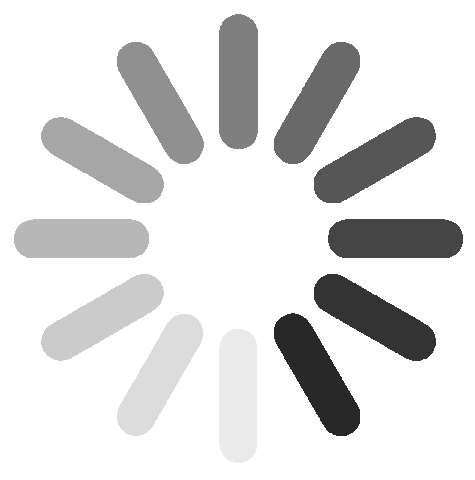

In [ ]:
dmp.create_interactive_plot(
    cooc_dmap,
    hover_text=[token for _, token in sorted(vz_cooc.token_index_dictionary_.items())],
    title="Tokens",
    sub_title="from cooccurrence over command lines",
    darkmode=True
)

Clearly, we're not wasting our time:
there are many tokens that are truly co-occurring strictly
(at the exclusion of co-occurring with others).
Leveraging this structure should yield a better data map.

So the same way that we can represent a command line as a set of weights on a categorical vocabulary,
we can represent it as a set of weights on a set of vectors, aka a _point cloud_.
In this case, we can understand the representation as being a _distribution_ on these vectors.
Fortunately, the structure we computed previously to represent the bag of words can be reused _as is_ from notebook 1.

In [ ]:
cmdlines_iwt = scipy.sparse.load_npz("cmdlines_iwt.npz")
cmdlines_iwt

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 236753 stored elements and shape (31046, 20906)>

The notion of similarity that is useful between distributions on point clouds is called the [Wasserstein distance](https://en.wikipedia.org/wiki/Wasserstein_metric).
Computing this distance between many distributions and deriving a vector space embedding for each distribution is called **Wasserstein embedding**,
and it involves the resolution of an optimal transport problem.
We have code for doing that in `vectorizers.WassersteinVectorizer`.
The following cell can take from 20 seconds to many minutes, depending on your computer.
Time to refill your mug?

In [ ]:
%%time
cmdlines_iwt_for_wass = cmdlines_iwt
if cmdlines_iwt_for_wass.shape[1] != cooc_vec.shape[0]:
    print(
        "Aligning cmdlines_iwt columns for sampled cooc_vec:",
        cmdlines_iwt_for_wass.shape,
        "->",
        (cmdlines_iwt_for_wass.shape[0], cooc_vec.shape[0]),
    )
    cmdlines_iwt_for_wass = cmdlines_iwt_for_wass[:, :cooc_vec.shape[0]]

row_mass = np.asarray(cmdlines_iwt_for_wass.sum(axis=1)).ravel()
wasserstein_row_mask = row_mass > 0
print(f"Keeping {wasserstein_row_mask.sum():,} / {len(wasserstein_row_mask):,} command lines with nonzero sampled token mass")
cmdlines_iwt_for_wass = cmdlines_iwt_for_wass[wasserstein_row_mask]
row_mass = row_mass[wasserstein_row_mask]

# Colab-safe finite fallback for sampled vocabularies: weighted expected token vectors.
cmdlines_wass = cmdlines_iwt_for_wass @ cooc_vec
cmdlines_wass = np.asarray(cmdlines_wass) / row_mass[:, None]
cmdlines_wass = np.nan_to_num(cmdlines_wass)
cmdlines_wass.shape

Keeping 31,046 / 31,046 command lines with nonzero sampled token mass
CPU times: user 209 ms, sys: 172 ms, total: 381 ms
Wall time: 384 ms


(31046, 512)

In [ ]:
%%time
cmdlines_iwt_for_wass = cmdlines_iwt
if cmdlines_iwt_for_wass.shape[1] != cooc_vec.shape[0]:
    print(
        "Aligning cmdlines_iwt columns for sampled cooc_vec:",
        cmdlines_iwt_for_wass.shape,
        "->",
        (cmdlines_iwt_for_wass.shape[0], cooc_vec.shape[0]),
    )
    cmdlines_iwt_for_wass = cmdlines_iwt_for_wass[:, :cooc_vec.shape[0]]

row_mass = np.asarray(cmdlines_iwt_for_wass.sum(axis=1)).ravel()
wasserstein_row_mask = row_mass > 0
print(f"Keeping {wasserstein_row_mask.sum():,} / {len(wasserstein_row_mask):,} command lines with nonzero sampled token mass")

cmdlines_iwt_for_wass = cmdlines_iwt_for_wass[wasserstein_row_mask]
row_mass = row_mass[wasserstein_row_mask]

# Colab-safe finite fallback for sampled vocabularies: weighted expected token vectors.
cmdlines_wass = cmdlines_iwt_for_wass @ cooc_vec
cmdlines_wass = np.asarray(cmdlines_wass) / row_mass[:, None]
cmdlines_wass = np.nan_to_num(cmdlines_wass)
cmdlines_wass.shape

Keeping 31,046 / 31,046 command lines with nonzero sampled token mass
CPU times: user 201 ms, sys: 180 ms, total: 381 ms
Wall time: 380 ms


(31046, 512)

Now crunch this down into a data map.
The Wasserstein-embedded vectors are best appraised for similarity through cosine distance.
This takes time once again.
Fling some angry birds at green pigs.

In [ ]:
%%time
wass_dmap = umap.UMAP(metric="cosine", init="pca", verbose=True).fit_transform(cmdlines_wass)
wass_dmap.shape

UMAP(angular_rp_forest=True, init='pca', metric='cosine', verbose=True)
Wed Jul 15 03:13:48 2026 Construct fuzzy simplicial set
Wed Jul 15 03:13:48 2026 Finding Nearest Neighbors
Wed Jul 15 03:13:48 2026 Building RP forest with 14 trees
Wed Jul 15 03:13:49 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	 5  /  15
	Stopping threshold met -- exiting after 5 iterations
Wed Jul 15 03:13:52 2026 Finished Nearest Neighbor Search
Wed Jul 15 03:13:53 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed Jul 15 03:14:19 2026 Finished embedding
CPU times: user 48.8 s, sys: 422 ms, total: 49.2 s
Wall time: 30.9 s


(31046, 2)

Let's fetch the same annotations we used for the [data map of notebook 1](Command%20lines%20-%20Bags%20of%20words.ipynb#datamap) and take a look.

In [ ]:
annotations = pd.read_parquet("cmdlines_labels_hovertext.parquet")
label_color_map = json.loads(Path("color_map.json").read_text(encoding="utf-8"))

<InteractiveFigure width=100% height=800>
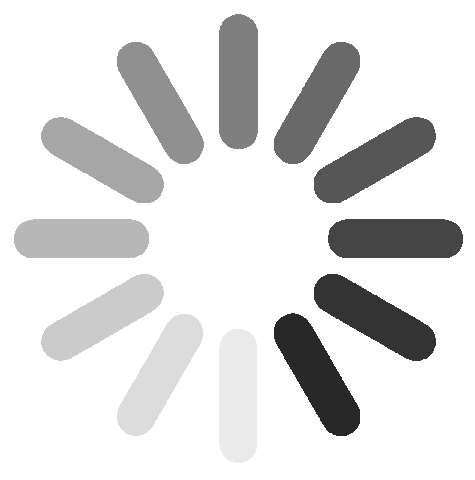

In [ ]:
annotations_for_plot = annotations.loc[wasserstein_row_mask].reset_index(drop=True)

plot_interactive = dmp.create_interactive_plot(
    wass_dmap,
    annotations_for_plot["labels"],
    hover_text=annotations_for_plot["hover_text"],
    darkmode=True,
    label_color_map=label_color_map,
    title="Process instances",
    sub_title="as sampled distributions on a point cloud of token cooccurrence vectors",
)
plot_interactive

This data map addresses many issues from that of notebook 1.
The immediate observation in support is that
most of the `msedge.exe` processes no longer form a world-spanning structure, but are rather lined up in two nearby clusters.
These clusters also accrete `chrome.exe` process instances,
which share many parameters with `msedge.exe` instances
(since both are browsers based on the same rendering engine).
`mergehelper.exe` process instances have also been cinched well close to each other.

A difficulty that hampers further comparison of the data maps is that UMAP computations have a strict random component.
Indeed, it relies on a multi-thread stochastic gradient descent iteration to solve a low-space projection problem,
which cannot be made deterministic by setting some random seed.

We will revisit the problem of comparing data map making methods in [notebook 5](5%20Comparing%20data%20maps.ipynb).
For this purpose, let's save the high-dimension vectors for this purpose.

In [ ]:
np.savez_compressed("cmdlines_wasserstein.npz", cmdlines=cmdlines_wass, datamap=wass_dmap)

In [ ]:
from huggingface_hub import HfApi

api = HfApi()

def upload_to_hugging_face_model_repo(repo_id, filename):
  api.upload_file(
    repo_id=repo_id,
    path_or_fileobj=filename,
    path_in_repo=filename,
    repo_type="model"
    )

upload_to_hugging_face_model_repo(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_wasserstein.npz")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../cmdlines_wasserstein.npz:   1%|          |  525kB / 79.7MB            